# Use Case 3 – Loan Amount Prediction

## Problem Statement

Build a regression model to predict the loan amount a customer is eligible for based on financial and demographic information.

### Target Variable

Loan_Amount

### Evaluation Metrics

- MAE
- MSE
- RMSE
- R² Score

In [89]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset

In [91]:
data = pd.read_csv(
    '/content/drive/MyDrive/Machine_Learning/datasets/preprocessed_hdfc_loan_data.csv'
)

In [92]:
data.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Unnamed: 39,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0,0,31,1,0,2,0,1,56976,0,...,2,NaN,2,0,5,857743,6.939290e+11,9068671773,31,8
1,1,0,31,1,0,0,0,3,1856,0,...,0,NaN,2,5,15,863836,6.325430e+11,9990772625,31,2
2,2,0,1,0,1,0,0,1,64553,0,...,2,NaN,2,4,19,834796,1.658050e+11,9195085016,1,12
3,3,0,4,1,0,0,0,1,88450,0,...,0,NaN,2,1,27,438590,5.528183e+10,9179335548,4,11
4,4,0,11,1,1,3,0,2,9539,0,...,1,NaN,4,9,12,495224,1.557790e+11,9795137116,11,14


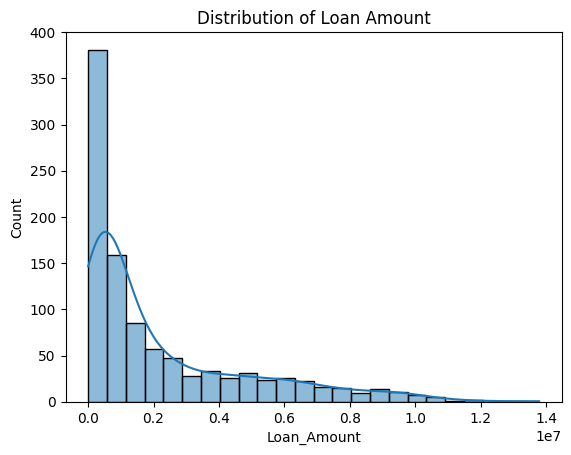

In [93]:
sns.histplot(
    data['Loan_Amount'],
    kde=True
)
plt.title('Distribution of Loan Amount')
plt.show()


# Feature Selection

Financial and demographic features are selected for predicting eligible loan amount.

In [94]:
features = [
    'Applicant_Income',
    'Annual_Household_Income',
    'Asset_Value',
    'Existing_EMIs',
    'Employment_Length_Years',
    'CIBIL_Score',
    'Monthly_Expense',
    'Debt_to_Income_Ratio',
    'Occupation',
    'Property_Area'
]

X = data[features]

y = data['Loan_Amount']

In [95]:
num_cols = [
    'Applicant_Income',
    'Annual_Household_Income',
    'Asset_Value',
    'Existing_EMIs',
    'Employment_Length_Years',
    'CIBIL_Score',
    'Monthly_Expense',
    'Debt_to_Income_Ratio'
]

In [96]:
for col in num_cols:

    data[col] = data[col].fillna(
        data[col].median()
    )

In [97]:
cat_cols = [
    'Occupation',
    'Property_Area'
]

In [98]:
for col in cat_cols:
  data[col] =data[col].fillna(data[col].mode()[0])

# Encode Categorical Features

Occupation and Property Area are categorical variables and must be converted into numerical form before training regression models.

In [99]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

for col in cat_cols:
  data[col] = le.fit_transform(data[col])


In [100]:
# define X and y
X = data[features]
y = data['Loan_Amount']

In [101]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_Income         1000 non-null   int64  
 1   Annual_Household_Income  1000 non-null   int64  
 2   Asset_Value              1000 non-null   int64  
 3   Existing_EMIs            1000 non-null   int64  
 4   Employment_Length_Years  1000 non-null   int64  
 5   CIBIL_Score              1000 non-null   int64  
 6   Monthly_Expense          1000 non-null   int64  
 7   Debt_to_Income_Ratio     1000 non-null   float64
 8   Occupation               1000 non-null   int64  
 9   Property_Area            1000 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 78.3 KB


# Train-Test Split

The dataset is divided into training and testing sets.

80% of the data is used for training and 20% is used for testing.

In [102]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Apply `StandardScaler` to the features. This is important for models like Linear Regression and can improve the performance of tree-based models, especially when features have different scales.

In [103]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train_scaled head:")
display(X_train_scaled.head())
print("X_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,Applicant_Income,Annual_Household_Income,Asset_Value,Existing_EMIs,Employment_Length_Years,CIBIL_Score,Monthly_Expense,Debt_to_Income_Ratio,Occupation,Property_Area
0,0.040237,-0.219062,-0.181829,-1.004204,-0.531186,-1.214876,0.164451,-0.083849,-0.530301,-0.010661
1,-0.454731,-0.129937,-0.273169,0.018001,-0.531186,-1.742855,0.052312,-0.083688,1.356051,1.207698
2,-1.222136,-1.126843,-1.298918,-0.849034,-0.884134,-0.673359,-1.207734,-0.083626,1.356051,1.207698
3,0.716195,1.420880,1.868032,0.641839,-0.884134,0.233681,1.577495,-0.083746,1.356051,1.207698
4,0.343587,-0.000921,-0.258392,-0.909317,-0.884134,-2.067765,0.418638,-0.083839,-1.473477,-1.229020


X_test_scaled head:


,Applicant_Income,Annual_Household_Income,Asset_Value,Existing_EMIs,Employment_Length_Years,CIBIL_Score,Monthly_Expense,Debt_to_Income_Ratio,Occupation,Property_Area
0,-1.341372,-1.172903,-0.548140,0.982412,0.527657,1.330253,-1.207734,-0.081467,-0.341665,1.207698
1,0.890256,0.392192,0.354637,2.349076,0.527657,0.260757,0.188549,-0.083483,0.601510,-0.010661
2,0.977072,2.237031,1.829356,-0.430086,0.880605,-0.145380,2.374823,-0.083832,-1.096206,-1.229020
3,-1.019747,-0.981304,-1.181917,-1.119368,-0.884134,0.463826,-0.864264,-0.083869,1.356051,1.207698
4,-0.905394,-0.552277,-0.400217,-0.553203,-0.884134,-1.675165,-0.318077,-0.083731,0.601510,-0.010661


# Model Building

Three regression algorithms are used:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

In [104]:
#Training Model 1 - Linear Regression
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [105]:
#Predict using Linear Regression
lr_pred = lr.predict(
    X_test_scaled
)

In [106]:
#Evaluation metrics of Linear Regression
mae = mean_absolute_error(
    y_test,
    lr_pred
)
mse = mean_squared_error(
    y_test,
    lr_pred
)
rmse = np.sqrt(mse)
r2 = r2_score(
    y_test,
    lr_pred
)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1979622.2912213837
MSE: 6130130285109.955
RMSE: 2475909.9913183344
R2: -0.010110700986451171


In [107]:
#Creating Evaluate function
def evaluate_regression(
    y_true,
    y_pred,
    model_name
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    mse = mean_squared_error(
        y_true,
        y_pred
    )
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_true,
        y_pred
    )
    print(f"\n{model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)

In [108]:
evaluate_regression(
    y_test,
    lr_pred,
    "Linear Regression"
)


Linear Regression
MAE: 1979622.2912213837
MSE: 6130130285109.955
RMSE: 2475909.9913183344
R2: -0.010110700986451171


In [109]:
#Training Model 2 - Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [110]:
#Predict using Random Forest Regressor
rf_pred = rf.predict(
    X_test
)

In [111]:
#Training Model 3 - Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(
    X_train,
    y_train
)

GradientBoostingRegressor(random_state=42)

In [112]:
#Predict using Gradient Boosting
gbr_pred = gbr.predict(
    X_test
)

In [113]:
#Evaluate Gradient Boosting
evaluate_regression(
    y_test,
    gbr_pred,
    "Gradient Boosting Regressor"
)


Gradient Boosting Regressor
MAE: 2134459.3621802293
MSE: 7396676315554.353
RMSE: 2719683.127784256
R2: -0.2188096419781842


In [114]:
#Calculate metrics for all models
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_test, gbr_pred)

#Create a results table for model performance comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_rmse, rf_rmse, gbr_rmse],
    "R2": [lr_r2, rf_r2, gbr_r2]
})

results

,Model,RMSE,R2
0,Linear Regression,2.475910e+06,-0.010111
1,Random Forest,2.721493e+06,-0.220432
2,Gradient Boosting,2.719683e+06,-0.218810


## Hyperparameter Tuning

Perform hyperparameter tuning using `GridSearchCV` for Random Forest Regressor and Gradient Boosting Regressor to find the best performing parameters. This addresses the 'Tune hyperparameters' task.

In [115]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}



In [116]:
grid= GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

In [78]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error', verbose=1)

In [79]:
print(f"Best parameters for Random Forest: {grid.best_params_}")
print(f"Best cross-validation score for Random Forest (negative MSE): {grid.best_score_}")

Best parameters for Random Forest: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score for Random Forest (negative MSE): -7375384398126.778


In [80]:
# Extracting best model

best_rf=grid.best_estimator_

In [81]:
best_pred = best_rf.predict(X_test)

In [82]:
# Evaluate tuned Model
evaluate_regression(
    y_test,
    best_pred,
    "Tuned Random Forest"
)


Tuned Random Forest
MAE: 2041426.5113498056
MSE: 6592790255779.466
RMSE: 2567642.9377503926
R2: -0.08634689264236273


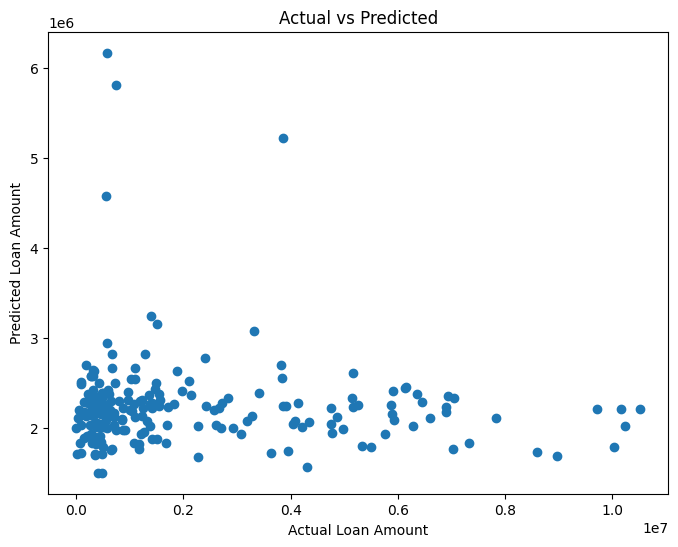

In [83]:
# Actual VS Predicted visulization
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_pred
)

plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Actual vs Predicted')

plt.show()


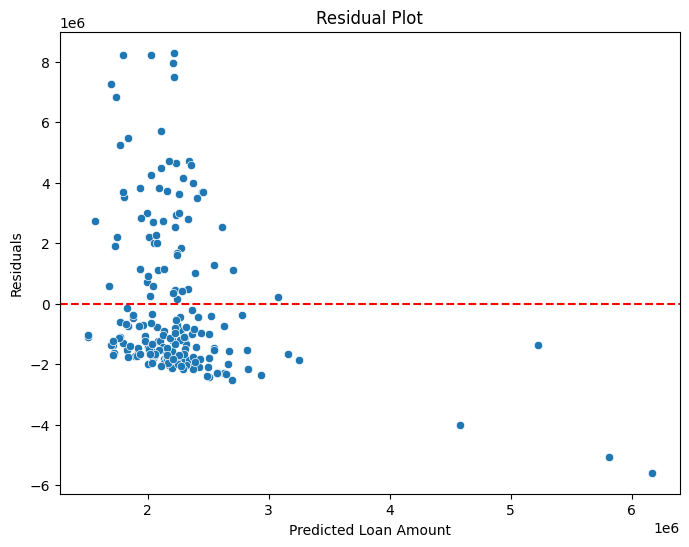

In [84]:
# residula Analysis plot
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted Loan Amount')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

# Feature Importance Analysis

The coefficients of Linear Regression are used to understand feature influence.

In [85]:
# Feature importance Analysis

importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,Asset_Value,0.152497
5,CIBIL_Score,0.151327
6,Monthly_Expense,0.128407
1,Annual_Household_Income,0.121619
3,Existing_EMIs,0.104742
0,Applicant_Income,0.104652
4,Employment_Length_Years,0.095219
7,Debt_to_Income_Ratio,0.064488
8,Occupation,0.055533
9,Property_Area,0.021516


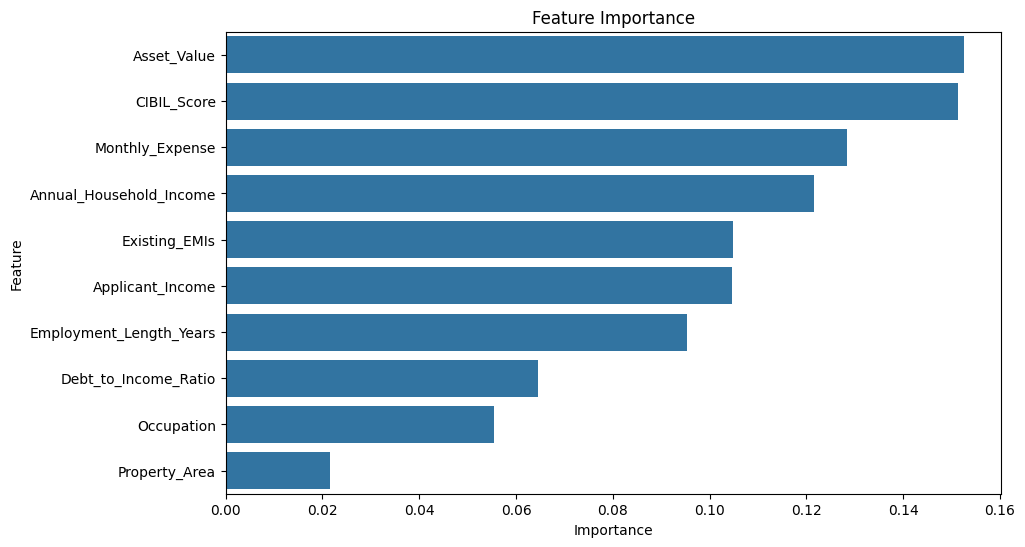

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

# Best Model Selection

Among the evaluated regression models, Linear Regression achieved the highest R² score.

Although the performance is low, it outperformed Random Forest Regressor and Gradient Boosting Regressor on this dataset.

In [87]:
#Create a model comparison table
best_mae = mean_absolute_error(y_test, best_pred)
best_mse = mean_squared_error(y_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_pred)

final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Tuned Random Forest'
    ],
    'MAE': [
        lr_mae,
        rf_mae,
        gbr_mae,
        best_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse,
        gbr_rmse,
        best_rmse
    ],
    'R2': [
        lr_r2,
        rf_r2,
        gbr_r2,
        best_r2
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Linear Regression,1.979622e+06,2.475910e+06,-0.010111
1,Random Forest,2.155421e+06,2.721493e+06,-0.220432
2,Gradient Boosting,2.134459e+06,2.719683e+06,-0.218810
3,Tuned Random Forest,2.041427e+06,2.567643e+06,-0.086347


In [88]:
import joblib

joblib.dump(
    lr_model,
    '/content/drive/MyDrive/Machine_Learning/models/loan_amount_prediction_model.pkl'
)

['/content/drive/MyDrive/Machine_Learning/models/loan_amount_prediction_model.pkl']

# Conclusion

Three regression models were developed to predict eligible loan amounts.

- Linear Regression performed better than Random Forest and Gradient Boosting.
- Correlation analysis revealed weak relationships between predictors and Loan Amount.
- Negative R² scores indicate that the dataset does not contain strong predictive patterns for loan amount estimation.
- Residual analysis and Actual vs Predicted plots were used to evaluate prediction behavior.
- The final Linear Regression model was saved for future use.

Future improvements may include adding more financial attributes and using a dataset with stronger feature-target relationships.